## 1 Data preparation

In [1]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

ENGINEERED_DIR = r"D:\uni\Intern-1-Project\ksl\dataset\Landmark\Full_data-landmark\landmarks_30frames_engineered_v2"
SEQUENCE_LENGTH = 30
FEATURES_PER_FRAME = 686  # Your engineered features

# ============================================================
# LOAD AND PREPARE DATA
# ============================================================

def load_data(base_dir):
    """
    Load all .npy files and create X (features) and y (labels)
    """
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f" Directory not found: {base_path}")
        return None, None
    
    X = []  # Features
    y = []  # Labels
    
    # Get all class folders
    class_folders = sorted([d for d in base_path.iterdir() if d.is_dir()])
    
    print(f"Found {len(class_folders)} classes")
    print("-" * 60)
    
    for class_idx, class_path in enumerate(class_folders):
        class_name = class_path.name
        npy_files = sorted(class_path.glob("*.npy"))
        
        print(f"  {class_idx}: {class_name} - {len(npy_files)} samples")
        
        for file_path in npy_files:
            try:
                data = np.load(file_path)
                
                # Ensure correct shape
                if data.shape != (SEQUENCE_LENGTH, FEATURES_PER_FRAME):
                    print(f"     Skipping {file_path.name}: shape {data.shape}")
                    continue
                
                X.append(data)
                y.append(class_idx)
                
            except Exception as e:
                print(f"     Error loading {file_path.name}: {e}")
    
    X = np.array(X)
    y = np.array(y)
    
    print("-" * 60)
    print(f" Total samples loaded: {len(X)}")
    print(f"   Shape: {X.shape}")
    print(f"   Classes: {len(np.unique(y))}")
    
    return X, y, [d.name for d in class_folders]

# Load data
X, y, class_names = load_data(ENGINEERED_DIR)

if X is None:
    print(" No data loaded!")
    exit()

Found 20 classes
------------------------------------------------------------
  0: កាតាប - 688 samples
  1: កាតាបស្ពាយក្រោយ - 579 samples
  2: កុំព្យូទ័រ - 814 samples
  3: កៅអី - 406 samples
  4: ក្ដារខៀន - 465 samples
  5: ខ្មៅដៃ - 683 samples
  6: ជ័រលុប - 490 samples
  7: ដីស - 545 samples
  8: តុ - 473 samples
  9: ទឹកលុប - 906 samples
  10: នាយករង - 509 samples
  11: នាយិកា - 730 samples
  12: បន្ទាត់ - 339 samples
  13: ប៊ិក - 688 samples
  14: ប៊ិកក្រហម - 1004 samples
  15: ប៊ិកខៀវ - 1109 samples
  16: សៀវភៅ - 529 samples
  17: ហ្វឺតក្រហម - 1028 samples
  18: ហ្វឺតខៀវ - 1008 samples
  19: ហ្វឺតខ្មៅ - 786 samples
------------------------------------------------------------
 Total samples loaded: 13779
   Shape: (13779, 30, 686)
   Classes: 20


## 2 Train test spilt

In [2]:
# ============================================================
# SPLIT DATA - 80% TRAINING, 20% FOR VAL + TEST
# ============================================================

def split_data(X, y, train_size=0.8, val_ratio=0.5):
    """
    Split data into train, validation, and test sets
    - 80% for training
    - Remaining 20% split equally between val and test (10% each)
    
    Args:
        train_size: Proportion for training (default: 0.8)
        val_ratio: Proportion of remaining data for validation (default: 0.5)
                   If 0.5, val and test are equal (10% each)
                   If 0.7, val=14%, test=6%
                   If 0.3, val=6%, test=14%
    """
    # First split: train and temp (val + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, 
        train_size=train_size, 
        random_state=42, 
        stratify=y
    )
    
    # Second split: val and test from temp
    val_size = val_ratio  # Proportion of temp for validation
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_ratio),
        random_state=42,
        stratify=y_temp
    )
    
    print("\n" + "=" * 70)
    print("DATA SPLIT SUMMARY")
    print("=" * 70)
    print(f"Total samples:  {len(X)}")
    print(f"Training:       {len(X_train):5d} ({len(X_train)/len(X)*100:5.1f}%)")
    print(f"Validation:     {len(X_val):5d} ({len(X_val)/len(X)*100:5.1f}%)")
    print(f"Test:           {len(X_test):5d} ({len(X_test)/len(X)*100:5.1f}%)")
    print("-" * 70)
    print(f"Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Use 80% training, 10% validation, 10% test
X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    X, y, 
    train_size=0.8,  # 80% training
    val_ratio=0.5    # 50% of remaining for val (10% of total)
)

# One-hot encode labels
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"\nClasses: {num_classes}")
print(f"Class names: {class_names}")

# Show per-class distribution in each split
print("\n" + "=" * 70)
print("PER-CLASS DISTRIBUTION IN SPLITS")
print("=" * 70)
print(f"{'Class':<20} {'Train':<8} {'Val':<8} {'Test':<8} {'Total':<8}")
print("-" * 70)

for i, class_name in enumerate(class_names):
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)
    total_count = train_count + val_count + test_count
    print(f"{class_name:<20} {train_count:<8} {val_count:<8} {test_count:<8} {total_count:<8}")



DATA SPLIT SUMMARY
Total samples:  13779
Training:       11023 ( 80.0%)
Validation:      1378 ( 10.0%)
Test:            1378 ( 10.0%)
----------------------------------------------------------------------
Train/Val/Test: 11023/1378/1378

Classes: 20
Class names: ['កាតាប', 'កាតាបស្ពាយក្រោយ', 'កុំព្យូទ័រ', 'កៅអី', 'ក្ដារខៀន', 'ខ្មៅដៃ', 'ជ័រលុប', 'ដីស', 'តុ', 'ទឹកលុប', 'នាយករង', 'នាយិកា', 'បន្ទាត់', 'ប៊ិក', 'ប៊ិកក្រហម', 'ប៊ិកខៀវ', 'សៀវភៅ', 'ហ្វឺតក្រហម', 'ហ្វឺតខៀវ', 'ហ្វឺតខ្មៅ']

PER-CLASS DISTRIBUTION IN SPLITS
Class                Train    Val      Test     Total   
----------------------------------------------------------------------
កាតាប                550      69       69       688     
កាតាបស្ពាយក្រោយ      463      58       58       579     
កុំព្យូទ័រ           651      81       82       814     
កៅអី                 325      41       40       406     
ក្ដារខៀន             372      47       46       465     
ខ្មៅដៃ               547      68       68       683     
ជ័រលុប         

## 3 Build model

In [3]:
import tensorflow as tf
from tensorflow.keras import layers

def build_blstm_with_attention(input_shape, num_classes):
    """
    Bidirectional LSTM with attention — reads sign forwards AND backwards
    Better than GRU for signs where the END (color gesture) matters most
    """
    inputs = tf.keras.Input(shape=input_shape)

    # Input normalization
    x = layers.BatchNormalization()(inputs)

    # 1D Conv to extract local patterns first
    x = layers.Conv1D(filters=64, kernel_size=3,
                      padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # BiLSTM layer 1 — reads both directions
    x = layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # BiLSTM layer 2 — deeper context
    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )(x)
    x = layers.Dropout(0.3)(x)

    # Attention — focus on important frames (especially end of sign)
    # BiLSTM output is 128 (64×2 from bidirectional)
    attention = layers.Dense(1, activation='tanh')(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(128)(attention)  # 64×2 = 128
    attention = layers.Permute([2, 1])(attention)

    # Apply attention weights
    x = layers.Multiply()([x, attention])
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs,
                          name='BiLSTM_Attention')


# ── Build ─────────────────────────────────────────────────────
input_shape = (SEQUENCE_LENGTH, FEATURES_PER_FRAME)
model       = build_blstm_with_attention(input_shape, num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 686)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 686)   │      2,744 │ input_layer[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │    131,776 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 128)   │    164,352 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 30)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 30)   │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 30, 128)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 128)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 509,165 (1.94 MB)

 Trainable params: 507,025 (1.93 MB)

 Non-trainable params: 2,140 (8.36 KB)

## 4 Model config

In [4]:
# ============================================================
# TRAIN WITH CALLBACKS & CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

def get_callbacks(model_save_path):
    """
    Create callbacks for training
    """
    callbacks = [
        # Early stopping - stop if no improvement
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        
        # Save best model
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    return callbacks

# ============================================================
# COMPUTE CLASS WEIGHTS (FOR IMBALANCED DATA)
# ============================================================

print("=" * 60)
print("COMPUTING CLASS WEIGHTS")
print("=" * 60)

# Calculate class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format for Keras
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Display class weights
print(f"\n{'Class':<25} {'Samples':<10} {'Weight':<10}")
print("-" * 60)
for i, class_name in enumerate(class_names):
    samples = np.sum(y_train == i)
    weight = class_weights[i]
    print(f"{class_name:<25} {samples:<10} {weight:<10.3f}")

print("\n" + "=" * 60)
print("CLASS WEIGHT SUMMARY")
print("=" * 60)
print(f"Min weight: {min(class_weights):.3f} (majority class)")
print(f"Max weight: {max(class_weights):.3f} (minority class)")
print(f"Weight ratio: {max(class_weights)/min(class_weights):.2f}x")

# ============================================================
# TRAIN THE MODEL WITH CLASS WEIGHTS
# ============================================================

# Model save path
MODEL_SAVE_PATH = r"D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v1.h5"

# Get callbacks
callbacks = get_callbacks(MODEL_SAVE_PATH)

# Train the model
print("\n" + "=" * 60)
print("STARTING TRAINING WITH CLASS WEIGHTS")
print("=" * 60)
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Classes:            {len(class_names)}")
print(f"Class weights:      Applied ✓")
print("-" * 60)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,  # ← This handles class imbalance!
    callbacks=callbacks,
    verbose=1
)


COMPUTING CLASS WEIGHTS

Class                     Samples    Weight    
------------------------------------------------------------
កាតាប                     449        1.037     
កាតាបស្ពាយក្រោយ           386        1.206     
កុំព្យូទ័រ                534        0.872     
កៅអី                      276        1.687     
ក្ដារខៀន                  287        1.623     
ខ្មៅដៃ                    457        1.019     
ជ័រលុប                    320        1.455     
ដីស                       346        1.346     
តុ                        325        1.433     
ទឹកលុប                    638        0.730     
នាយករង                    344        1.354     
នាយិកា                    502        0.928     
បន្ទាត់                   213        2.186     
ប៊ិក                      466        0.999     
ប៊ិកក្រហម                 705        0.661     
ប៊ិកខៀវ                   769        0.606     
សៀវភៅ                     370        1.259     
ហ្វឺតក្រហម                716        0.650     
ហ្

292/292 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.2850 - loss: 2.2200 - val_accuracy: 0.6048 - val_loss: 2.0470 - learning_rate: 0.0010
Epoch 2/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6213 - loss: 0.8979
Epoch 2: val_accuracy improved from 0.60481 to 0.73883, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.6214 - loss: 0.8977 - val_accuracy: 0.7388 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 3/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6914 - loss: 0.6578
Epoch 3: val_accuracy improved from 0.73883 to 0.78007, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.6914 - loss: 0.6577 - val_accuracy: 0.7801 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 4/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7140 - loss: 0.5870
Epoch 4: val_accuracy did not improve from 0.78007
292/292 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.7141 - loss: 0.5869 - val_accuracy: 0.7603 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 5/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7350 - loss: 0.5123
Epoch 5: val_accuracy improved from 0.78007 to 0.78866, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v1.h5


292/292 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.7350 - loss: 0.5123 - val_accuracy: 0.7887 - val_loss: 0.4366 - learning_rate: 0.0010
Epoch 6/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7447 - loss: 0.4832
Epoch 6: val_accuracy did not improve from 0.78866
292/292 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - accuracy: 0.7447 - loss: 0.4832 - val_accuracy: 0.7852 - val_loss: 0.4305 - learning_rate: 0.0010
Epoch 7/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7654 - loss: 0.4441
Epoch 7: val_accuracy improved from 0.78866 to 0.80069, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v1.h5


...

292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 86ms/step - accuracy: 0.8781 - loss: 0.2265 - val_accuracy: 0.9261 - val_loss: 0.2348 - learning_rate: 0.0010
Epoch 62/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8880 - loss: 0.2018
Epoch 62: val_accuracy did not improve from 0.92612
292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.8880 - loss: 0.2018 - val_accuracy: 0.9081 - val_loss: 0.2391 - learning_rate: 0.0010
Epoch 63/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8831 - loss: 0.2083
Epoch 63: val_accuracy did not improve from 0.92612
292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.8831 - loss: 0.2083 - val_accuracy: 0.9029 - val_loss: 0.2517 - learning_rate: 0.0010
Epoch 64/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8830 - loss: 0.2252
Epoch 64: val_accuracy did not improve from 0.92612
292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 86ms/step - accuracy: 0.8830 - loss: 0.2252 - val_accuracy: 0.9192 - val_loss: 0.2184 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.8999 - loss: 0.1845 - val_accuracy: 0.9313 - val_loss: 0.2059 - learning_rate: 0.0010
Epoch 80/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9059 - loss: 0.1792
Epoch 80: val_accuracy did not improve from 0.93127
292/292 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.9059 - loss: 0.1792 - val_accuracy: 0.9235 - val_loss: 0.2048 - learning_rate: 0.0010
Epoch 81/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9061 - loss: 0.1813
Epoch 81: val_accuracy did not improve from 0.93127
292/292 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.9061 - loss: 0.1813 - val_accuracy: 0.9141 - val_loss: 0.2146 - learning_rate: 0.0010
Epoch 82/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8934 - loss: 0.2047
Epoch 82: val_accuracy did not improve from 0.93127
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.8934 - loss: 0.2047 - val_accuracy: 0.9270 - val_loss: 0.2074 - learning_rate: 0.0010
Epoch

292/292 ━━━━━━━━━━━━━━━━━━━━ 35s 119ms/step - accuracy: 0.9015 - loss: 0.1815 - val_accuracy: 0.9399 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 85/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9046 - loss: 0.1841
Epoch 85: val_accuracy did not improve from 0.93986
292/292 ━━━━━━━━━━━━━━━━━━━━ 32s 109ms/step - accuracy: 0.9046 - loss: 0.1841 - val_accuracy: 0.9270 - val_loss: 0.1957 - learning_rate: 0.0010
Epoch 86/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9036 - loss: 0.1878
Epoch 86: val_accuracy did not improve from 0.93986
292/292 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - accuracy: 0.9036 - loss: 0.1878 - val_accuracy: 0.9278 - val_loss: 0.2071 - learning_rate: 0.0010
Epoch 87/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9027 - loss: 0.1894
Epoch 87: val_accuracy did not improve from 0.93986
292/292 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.9027 - loss: 0.1894 - val_accuracy: 0.9356 - val_loss: 0.1998 - learning_rate: 0.0010


292/292 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.9208 - loss: 0.1511 - val_accuracy: 0.9442 - val_loss: 0.1840 - learning_rate: 5.0000e-04
Epoch 97/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9223 - loss: 0.1516
Epoch 97: val_accuracy did not improve from 0.94416
292/292 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.9223 - loss: 0.1516 - val_accuracy: 0.9381 - val_loss: 0.1875 - learning_rate: 5.0000e-04
Epoch 98/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9263 - loss: 0.1472
Epoch 98: val_accuracy did not improve from 0.94416
292/292 ━━━━━━━━━━━━━━━━━━━━ 46s 159ms/step - accuracy: 0.9263 - loss: 0.1473 - val_accuracy: 0.9424 - val_loss: 0.1852 - learning_rate: 5.0000e-04
Epoch 99/100
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9263 - loss: 0.1487
Epoch 99: val_accuracy did not improve from 0.94416
292/292 ━━━━━━━━━━━━━━━━━━━━ 92s 191ms/step - accuracy: 0.9263 - loss: 0.1487 - val_accuracy: 0.9390 - val_loss: 0.1882 - learning_ra

292/292 ━━━━━━━━━━━━━━━━━━━━ 54s 96ms/step - accuracy: 0.9224 - loss: 0.1506 - val_accuracy: 0.9459 - val_loss: 0.1896 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 96.


### Train on full data 

In [4]:
# ============================================================
# TRAIN WITH CALLBACKS & CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

def get_callbacks(model_save_path):
    """
    Create callbacks for training
    """
    callbacks = [
        # Early stopping - stop if no improvement
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate on plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        
        # Save best model
        tf.keras.callbacks.ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]
    
    return callbacks

# ============================================================
# COMPUTE CLASS WEIGHTS (FOR IMBALANCED DATA)
# ============================================================

print("=" * 60)
print("COMPUTING CLASS WEIGHTS")
print("=" * 60)

# Calculate class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format for Keras
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Display class weights
print(f"\n{'Class':<25} {'Samples':<10} {'Weight':<10}")
print("-" * 60)
for i, class_name in enumerate(class_names):
    samples = np.sum(y_train == i)
    weight = class_weights[i]
    print(f"{class_name:<25} {samples:<10} {weight:<10.3f}")

print("\n" + "=" * 60)
print("CLASS WEIGHT SUMMARY")
print("=" * 60)
print(f"Min weight: {min(class_weights):.3f} (majority class)")
print(f"Max weight: {max(class_weights):.3f} (minority class)")
print(f"Weight ratio: {max(class_weights)/min(class_weights):.2f}x")

# ============================================================
# TRAIN THE MODEL WITH CLASS WEIGHTS
# ============================================================

# Model save path
MODEL_SAVE_PATH = r"D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5"

# Get callbacks
callbacks = get_callbacks(MODEL_SAVE_PATH)

# Train the model
print("\n" + "=" * 60)
print("STARTING TRAINING WITH CLASS WEIGHTS")
print("=" * 60)
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Classes:            {len(class_names)}")
print(f"Class weights:      Applied ✓")
print("-" * 60)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,  # ← This handles class imbalance!
    callbacks=callbacks,
    verbose=1
)


COMPUTING CLASS WEIGHTS

Class                     Samples    Weight    
------------------------------------------------------------
កាតាប                     550        1.002     
កាតាបស្ពាយក្រោយ           463        1.190     
កុំព្យូទ័រ                651        0.847     
កៅអី                      325        1.696     
ក្ដារខៀន                  372        1.482     
ខ្មៅដៃ                    547        1.008     
ជ័រលុប                    392        1.406     
ដីស                       436        1.264     
តុ                        379        1.454     
ទឹកលុប                    725        0.760     
នាយករង                    407        1.354     
នាយិកា                    584        0.944     
បន្ទាត់                   271        2.034     
ប៊ិក                      551        1.000     
ប៊ិកក្រហម                 803        0.686     
ប៊ិកខៀវ                   887        0.621     
សៀវភៅ                     423        1.303     
ហ្វឺតក្រហម                822        0.670     
ហ្

345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.2798 - loss: 2.2254 - val_accuracy: 0.5907 - val_loss: 1.7203 - learning_rate: 0.0010
Epoch 2/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5970 - loss: 0.9773
Epoch 2: val_accuracy improved from 0.59071 to 0.68940, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.5971 - loss: 0.9771 - val_accuracy: 0.6894 - val_loss: 0.7401 - learning_rate: 0.0010
Epoch 3/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6465 - loss: 0.7966
Epoch 3: val_accuracy improved from 0.68940 to 0.73367, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.6466 - loss: 0.7966 - val_accuracy: 0.7337 - val_loss: 0.5871 - learning_rate: 0.0010
Epoch 4/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6860 - loss: 0.6807
Epoch 4: val_accuracy improved from 0.73367 to 0.76415, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 31s 88ms/step - accuracy: 0.6860 - loss: 0.6806 - val_accuracy: 0.7642 - val_loss: 0.5449 - learning_rate: 0.0010
Epoch 5/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7059 - loss: 0.6283
Epoch 5: val_accuracy did not improve from 0.76415
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.7059 - loss: 0.6283 - val_accuracy: 0.7576 - val_loss: 0.5152 - learning_rate: 0.0010
Epoch 6/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7187 - loss: 0.5824
Epoch 6: val_accuracy improved from 0.76415 to 0.77721, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5


...

345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.8941 - loss: 0.1955 - val_accuracy: 0.9107 - val_loss: 0.2361 - learning_rate: 5.0000e-04
Epoch 71/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8914 - loss: 0.2033
Epoch 71: val_accuracy did not improve from 0.91074
345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.8914 - loss: 0.2033 - val_accuracy: 0.9035 - val_loss: 0.2304 - learning_rate: 5.0000e-04
Epoch 72/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8901 - loss: 0.2136
Epoch 72: val_accuracy did not improve from 0.91074
345/345 ━━━━━━━━━━━━━━━━━━━━ 44s 129ms/step - accuracy: 0.8901 - loss: 0.2136 - val_accuracy: 0.9035 - val_loss: 0.2376 - learning_rate: 5.0000e-04
Epoch 73/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8894 - loss: 0.2066
Epoch 73: val_accuracy did not improve from 0.91074
345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 81ms/step - accuracy: 0.8894 - loss: 0.2066 - val_accuracy: 0.9042 - val_loss: 0.2376 - learning_rate

345/345 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.8942 - loss: 0.1927 - val_accuracy: 0.9144 - val_loss: 0.2189 - learning_rate: 5.0000e-04
Epoch 75/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8955 - loss: 0.1940
Epoch 75: val_accuracy did not improve from 0.91437
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.8955 - loss: 0.1940 - val_accuracy: 0.9093 - val_loss: 0.2348 - learning_rate: 5.0000e-04
Epoch 76/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9006 - loss: 0.1845
Epoch 76: val_accuracy did not improve from 0.91437
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.9006 - loss: 0.1845 - val_accuracy: 0.9107 - val_loss: 0.2153 - learning_rate: 5.0000e-04
Epoch 77/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8965 - loss: 0.2000
Epoch 77: val_accuracy did not improve from 0.91437
345/345 ━━━━━━━━━━━━━━━━━━━━ 30s 86ms/step - accuracy: 0.8965 - loss: 0.2000 - val_accuracy: 0.9078 - val_loss: 0.2253 - learning_rate: 

345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.8954 - loss: 0.1976 - val_accuracy: 0.9173 - val_loss: 0.2150 - learning_rate: 5.0000e-04
Epoch 79/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8966 - loss: 0.1845
Epoch 79: val_accuracy did not improve from 0.91727
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.8966 - loss: 0.1845 - val_accuracy: 0.9122 - val_loss: 0.2171 - learning_rate: 5.0000e-04
Epoch 80/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9024 - loss: 0.1839
Epoch 80: val_accuracy improved from 0.91727 to 0.91800, saving model to D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.9024 - loss: 0.1839 - val_accuracy: 0.9180 - val_loss: 0.2149 - learning_rate: 5.0000e-04
Epoch 81/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9061 - loss: 0.1841
Epoch 81: val_accuracy did not improve from 0.91800
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.9061 - loss: 0.1841 - val_accuracy: 0.9071 - val_loss: 0.2243 - learning_rate: 5.0000e-04
Epoch 82/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8984 - loss: 0.1857
Epoch 82: val_accuracy did not improve from 0.91800
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.8984 - loss: 0.1857 - val_accuracy: 0.9136 - val_loss: 0.2081 - learning_rate: 5.0000e-04
Epoch 83/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9003 - loss: 0.1894
Epoch 83: val_accuracy did not improve from 0.91800
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.9003 - loss: 0.1894 - val_accuracy: 0.9136 - val_loss: 0.2181 - learning_rate:

345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.9020 - loss: 0.1833 - val_accuracy: 0.9209 - val_loss: 0.2219 - learning_rate: 5.0000e-04
Epoch 89/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9088 - loss: 0.1729
Epoch 89: val_accuracy did not improve from 0.92090
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.9088 - loss: 0.1729 - val_accuracy: 0.9144 - val_loss: 0.2268 - learning_rate: 5.0000e-04
Epoch 90/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9041 - loss: 0.1701
Epoch 90: val_accuracy did not improve from 0.92090
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.9041 - loss: 0.1701 - val_accuracy: 0.9064 - val_loss: 0.2282 - learning_rate: 5.0000e-04
Epoch 91/100
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9041 - loss: 0.1786
Epoch 91: val_accuracy did not improve from 0.92090
345/345 ━━━━━━━━━━━━━━━━━━━━ 29s 84ms/step - accuracy: 0.9041 - loss: 0.1786 - val_accuracy: 0.9180 - val_loss: 0.2298 - learning_rate: 

## 5 model evaluation 

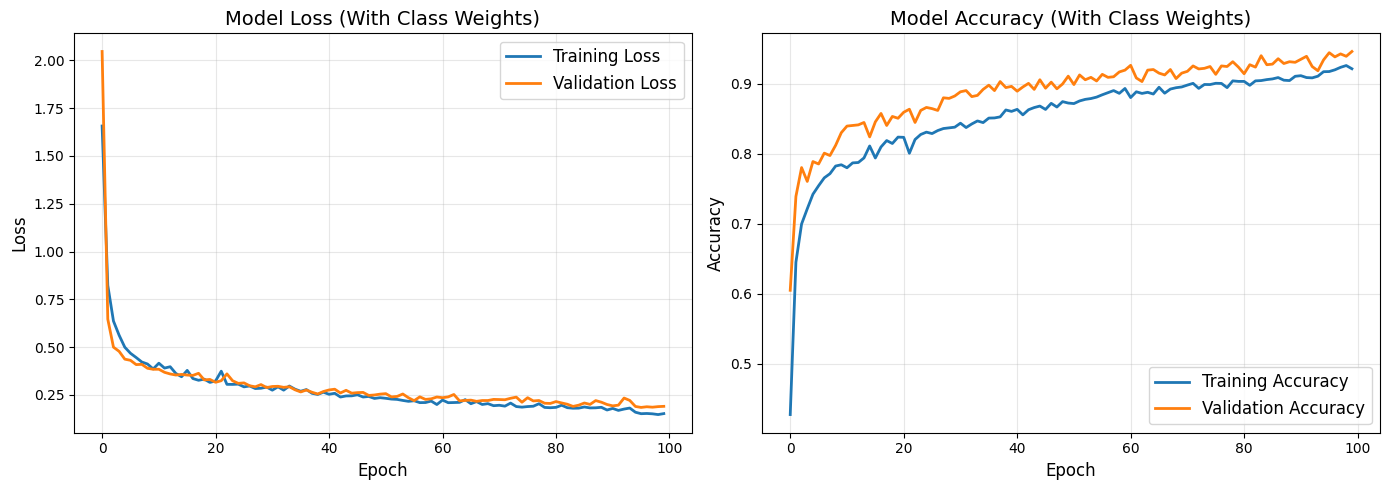


TEST SET EVALUATION
Test Loss:     0.1643
Test Accuracy: 0.9408 (94.08%)

PER-CLASS ACCURACY (With Class Weights)

Class                     Accuracy     Samples    Status    
-----------------------------------------------------------------
កាតាប                     100.00%     56          Good     
កាតាបស្ពាយក្រោយ            95.83%     48          Good     
កុំព្យូទ័រ                 98.51%     67          Good     
កៅអី                      100.00%     34          Good     
ក្ដារខៀន                   97.22%     36          Good     
ខ្មៅដៃ                    100.00%     57          Good     
ជ័រលុប                    100.00%     40          Good     
ដីស                        97.67%     43          Good     
តុ                        100.00%     40          Good     
ទឹកលុប                    100.00%     80          Good     
នាយករង                    100.00%     43          Good     
នាយិកា                    100.00%     63          Good     
បន្ទាត់                   100.00%    

c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6016 (\N{KHMER LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6070 (\N{KHMER VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6031 (\N{KHMER LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6036 (\N{KHMER LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 6047 (\N{KHMER LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\User\miniconda3\envs\sign_lang_fixed\lib\site-packages\seaborn

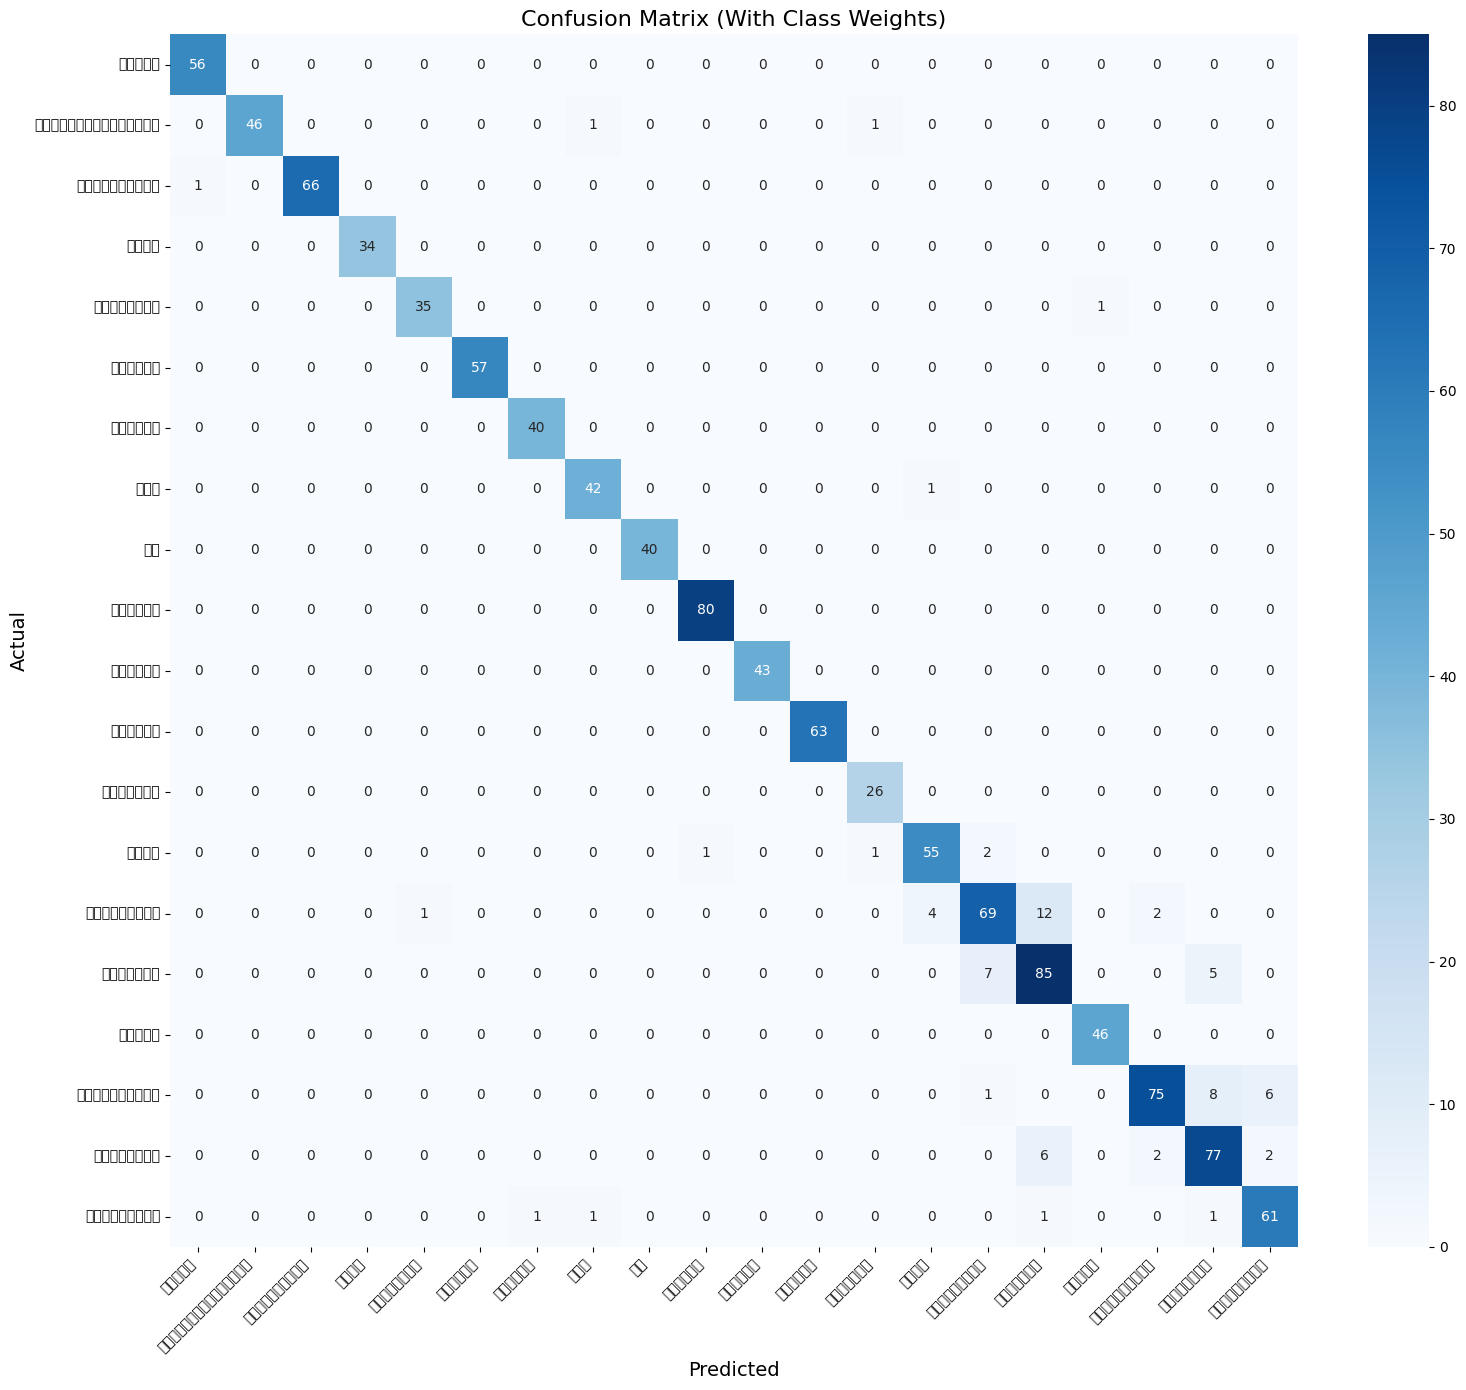


CLASSIFICATION REPORT
                 precision    recall  f1-score   support

          កាតាប       0.98      1.00      0.99        56
កាតាបស្ពាយក្រោយ       1.00      0.96      0.98        48
     កុំព្យូទ័រ       1.00      0.99      0.99        67
           កៅអី       1.00      1.00      1.00        34
       ក្ដារខៀន       0.97      0.97      0.97        36
         ខ្មៅដៃ       1.00      1.00      1.00        57
         ជ័រលុប       0.98      1.00      0.99        40
            ដីស       0.95      0.98      0.97        43
             តុ       1.00      1.00      1.00        40
         ទឹកលុប       0.99      1.00      0.99        80
         នាយករង       1.00      1.00      1.00        43
         នាយិកា       1.00      1.00      1.00        63
        បន្ទាត់       0.93      1.00      0.96        26
           ប៊ិក       0.92      0.93      0.92        59
      ប៊ិកក្រហម       0.87      0.78      0.83        88
        ប៊ិកខៀវ       0.82      0.88      0.85        97
       

In [5]:
# ============================================================
# VISUALIZE TRAINING HISTORY
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history):
    """
    Plot training and validation loss/accuracy
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Model Loss (With Class Weights)', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('Model Accuracy (With Class Weights)', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{Path(MODEL_SAVE_PATH).parent}/training_history.png", dpi=150)
    plt.show()

# Plot training history
plot_training_history(history)

# ============================================================
# EVALUATE ON TEST SET
# ============================================================

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ============================================================
# PER-CLASS ACCURACY (Most important for imbalanced data)
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "=" * 60)
print("PER-CLASS ACCURACY (With Class Weights)")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_classes)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print(f"\n{'Class':<25} {'Accuracy':<12} {'Samples':<10} {'Status':<10}")
print("-" * 65)

problematic = []
for i, class_name in enumerate(class_names):
    acc = class_accuracy[i]
    samples = np.sum(y_test == i)
    status = " Good" if acc >= 0.8 else " Okay" if acc >= 0.7 else " Poor"
    print(f"{class_name:<25} {acc*100:>6.2f}%     {samples:<10} {status:<10}")
    if acc < 0.7:
        problematic.append((class_name, acc))

# Show problematic classes
if problematic:
    print("\n" + "=" * 60)
    print(" PROBLEMATIC CLASSES (Below 70% Accuracy)")
    print("=" * 60)
    for class_name, acc in problematic:
        print(f"  - {class_name}: {acc*100:.2f}%")
    print("\n Consider:")
    print("  - Adding more samples for these classes")
    print("  - Trying data augmentation")
    print("  - Adjusting model architecture")
else:
    print("\n" + "=" * 60)
    print(" ALL CLASSES ABOVE 70% ACCURACY!")
    print("   Class weights are working well!")
    print("=" * 60)

# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (With Class Weights)', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{Path(MODEL_SAVE_PATH).parent}/confusion_matrix.png", dpi=150)
plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

## 6 Save model

In [6]:
# ============================================================
# SAVE MODEL AND HISTORY
# ============================================================

import pickle
import json 
# Save the model
model.save(MODEL_SAVE_PATH)
print(f"\n Model saved to: {MODEL_SAVE_PATH}")

# Save class names
# Save as pickle (for Python)
with open(f"{Path(MODEL_SAVE_PATH).parent}/class_names_blstm.pkl", 'wb') as f:
    pickle.dump(class_names, f)
print(f" Class names saved to: class_names_blstm.pkl")

# Save as JSON (more universal, readable)
with open(f"{Path(MODEL_SAVE_PATH).parent}/label_map_blstm.json", 'w', encoding='utf-8') as f:
    json.dump({
        str(i): class_name for i, class_name in enumerate(class_names)
    }, f, ensure_ascii=False, indent=2)
print(f" Label map saved to: label_map_blstm.json")

# Save training history
with open(f"{Path(MODEL_SAVE_PATH).parent}/training_history_blstm.pkl", 'wb') as f:
    pickle.dump(history.history, f)
print(f" Training history saved to: {Path(MODEL_SAVE_PATH).parent}/training_history_blstm.pkl")

print("\n" + "=" * 60)
print(" TRAINING COMPLETE!")
print("=" * 60)


 Model saved to: D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v1.h5
 Class names saved to: class_names_blstm.pkl
 Label map saved to: label_map_blstm.json
 Training history saved to: D:\uni\Intern-1-Project\ksl\models/training_history_blstm.pkl

 TRAINING COMPLETE!


### Save model on full data 

In [6]:
# ============================================================
# SAVE MODEL AND HISTORY
# ============================================================

import pickle
import json 
# Save the model
model.save(MODEL_SAVE_PATH)
print(f"\n Model saved to: {MODEL_SAVE_PATH}")

# Save class names
# Save as pickle (for Python)
with open(f"{Path(MODEL_SAVE_PATH).parent}/class_names_blstm_v2.pkl", 'wb') as f:
    pickle.dump(class_names, f)
print(f" Class names saved to: class_names_blstm_v2.pkl")

# Save as JSON (more universal, readable)
with open(f"{Path(MODEL_SAVE_PATH).parent}/label_map_blstm_v2.json", 'w', encoding='utf-8') as f:
    json.dump({
        str(i): class_name for i, class_name in enumerate(class_names)
    }, f, ensure_ascii=False, indent=2)
print(f" Label map saved to: label_map_blstm_v2.json")

# Save training history
with open(f"{Path(MODEL_SAVE_PATH).parent}/training_history_blstm_v2.pkl", 'wb') as f:
    pickle.dump(history.history, f)
print(f" Training history saved to: {Path(MODEL_SAVE_PATH).parent}/training_history_blstm_v2.pkl")

print("\n" + "=" * 60)
print(" TRAINING COMPLETE!")
print("=" * 60)


 Model saved to: D:/uni/Intern-1-Project/ksl/models/blstm_best_model_v2.h5
 Class names saved to: class_names_blstm_v2.pkl
 Label map saved to: label_map_blstm_v2.json
 Training history saved to: D:\uni\Intern-1-Project\ksl\models/training_history_blstm_v2.pkl

 TRAINING COMPLETE!
